In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..'))
from utils import get_spike_activity, sdf, sdf_mean
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
rooth_path = "/home/csartor1/code/NODS/results/"
with open("/home/csartor1/code/NODS/network_configuration.json", "r") as json_file:
    net_config = json.load(json_file)

CS_burst_dur = net_config["devices"]["CS"]["parameters"]["burst_dur"]
CS_start_first = float(net_config["devices"]["CS"]["parameters"]["start_first"])
between_start = net_config["devices"]["CS"]["parameters"]["between_start"]
n_trials = net_config["devices"]["CS"]["parameters"]["n_trials"]
US_start_first = float(net_config["devices"]["US"]["parameters"]["start_first"])

cell_color = net_config["cell_types"]["purkinje_cell"]["color"][0]
CS_color = net_config["colors"]["CS"]
US_color = net_config["colors"]["US"]
with_NO_color = net_config["devices"]["nNOS"]["color"][0]
without_NO_color = "#000000"

In [3]:
palette = list(reversed(sns.color_palette("viridis", n_trials).as_hex()))
sm = plt.cm.ScalarMappable(cmap="viridis_r", norm=plt.Normalize(vmin=0, vmax=n_trials))

In [ ]:
cell = "pc_spikes"
result_path = rooth_path+"wo_NO/4Hz/"

sdf_mean_trials_simulations = []
sdf_mean_cell = []
for k in range(5):
    file_path = result_path+ f"sim_{k+1}/"
    print(f"sim_{k+1}", flush=True)
    sdf_mean_over_trials = []
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0]
    intervals = [(500,1000), (14500,15000)]

    for start, end in intervals:
        mask = (times >= start) & (times <= end)
        filtered_times = times[mask]
        filtered_ids = ID_cell[mask]

    # Convert results back to numpy arrays for consistency
        filtered_times = np.array(filtered_times)
        filtered_ids = np.array(filtered_ids)

        plt.figure()
        plt.axvline(CS_start_first+start, label="CS start", linewidth=3, c=CS_color)
        plt.axvline(US_start_first - between_start + start, label="US start", linewidth=3, c=US_color)
        plt.axvline(CS_start_first + CS_burst_dur + start, label="CS & US end ", linewidth=3, c="#E1D5E7")
        plt.scatter(filtered_times,filtered_ids, s = 1)
        plt.title(f"standard STDP trial {int(end/500)}")
        plt.ylabel("SDF [Hz]")
        plt.xlabel("Time [ms]")
        plt.legend()
        plt.show()


In [ ]:
cell = "pc_spikes"
result_path = rooth_path+"test/thr_60/"

sdf_mean_trials_simulations = []
sdf_mean_cell = []
for k in range(5):
    file_path = result_path+ f"sim_{k+1}/"
    print(f"sim_{k+1}", flush=True)
    sdf_mean_over_trials = []
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0]
    intervals = [(500,1000), (14500,15000)]

    for start, end in intervals:
        mask = (times >= start) & (times <= end)
        filtered_times = times[mask]
        filtered_ids = ID_cell[mask]

    # Convert results back to numpy arrays for consistency
        filtered_times = np.array(filtered_times)
        filtered_ids = np.array(filtered_ids)

        plt.figure()
        plt.axvline(CS_start_first+start, label="CS start", linewidth=3, c=CS_color)
        plt.axvline(US_start_first - between_start + start, label="US start", linewidth=3, c=US_color)
        plt.axvline(CS_start_first + CS_burst_dur + start, label="CS & US end ", linewidth=3, c="#E1D5E7")
        plt.scatter(filtered_times,filtered_ids, s = 1)
        plt.title(f"NO-Dependent STDP trial {int(end/500)} thr: 60")
        plt.ylabel("SDF [Hz]")
        plt.xlabel("Time [ms]")
        plt.legend()
        plt.show()

In [ ]:
cell = "pc_spikes"
result_path = rooth_path+"test/thr_100/"

sdf_mean_trials_simulations = []
sdf_mean_cell = []
for k in range(5):
    file_path = result_path+ f"sim_{k+1}/"
    print(f"sim_{k+1}", flush=True)
    sdf_mean_over_trials = []
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0]
    intervals = [(500,1000), (14500,15000)]

    for start, end in intervals:
        mask = (times >= start) & (times <= end)
        filtered_times = times[mask]
        filtered_ids = ID_cell[mask]

    # Convert results back to numpy arrays for consistency
        filtered_times = np.array(filtered_times)
        filtered_ids = np.array(filtered_ids)

        plt.figure()
        plt.axvline(CS_start_first+start, label="CS start", linewidth=3, c=CS_color)
        plt.axvline(US_start_first - between_start + start, label="US start", linewidth=3, c=US_color)
        plt.axvline(CS_start_first + CS_burst_dur + start, label="CS & US end ", linewidth=3, c="#E1D5E7")
        plt.scatter(filtered_times,filtered_ids, s = 1)
        plt.title(f"NO-Dependent STDP trial {int(end/500)} thr: 100")
        plt.ylabel("SDF [Hz]")
        plt.xlabel("Time [ms]")
        plt.legend()
        plt.show()

In [ ]:
# heatmaps of number of spikes for every PC
result_path = rooth_path+"wo_NO/4Hz/"
cell = 'pc_spikes'
spk = get_spike_activity(cell_name=cell, path=result_path)
times = spk[:,1]
ID_cell = spk[:,0].astype(int)
time_bin = 50
trial_len = between_start
pc_ids = np.unique(ID_cell)
pc_spikes_matrix_trial_2 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin)))
pc_spikes_matrix_trial_30 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin)))
pc_spikes_matrix_trial_diff = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin)))
intervals = [(500,1000), (14500,15000)]
for i,interval in enumerate(intervals):
    for j,t_interval in enumerate(range(interval[0],interval[1],time_bin)):
        start = t_interval
        end = t_interval+time_bin
        mask = (times >= start) & (times <= end)
        filtered_ids = ID_cell[mask]


        for id in np.unique(filtered_ids):
            count_spikes = len(np.where(filtered_ids==id)[0])
            ind_pc_id = np.where(pc_ids == id)[0]
            if i == 0:
                pc_spikes_matrix_trial_2[ind_pc_id,j] = count_spikes
            else:
                pc_spikes_matrix_trial_30[ind_pc_id,j] = count_spikes

pc_spikes_matrix_trial_diff = pc_spikes_matrix_trial_30 - pc_spikes_matrix_trial_2

/tmp/ipykernel_2991295/2437457333.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


Text(0.5, 1.0, 'pc spikes count trial 2')

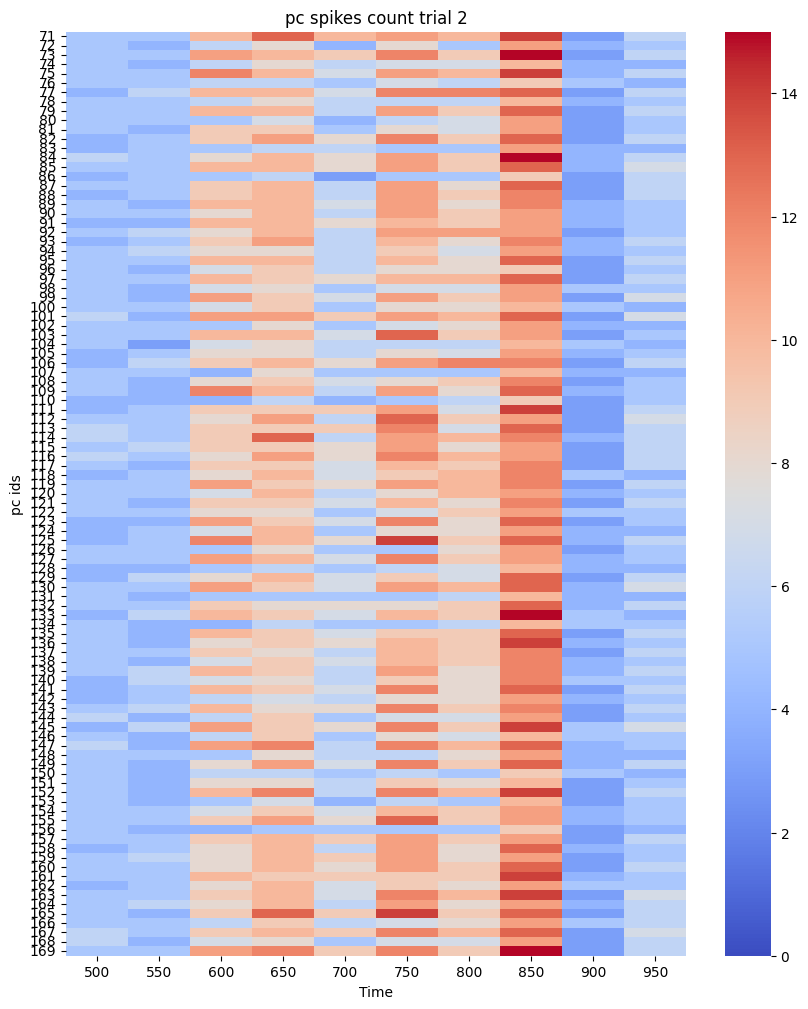

In [36]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(10,12))
sns.heatmap(pc_spikes_matrix_trial_2, 
            cmap = cmap, 
            xticklabels=range(intervals[0][0], intervals[0][1], time_bin), 
            yticklabels=pc_ids,
            vmin = 0,
            vmax = 15
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('pc spikes count trial 2')


/tmp/ipykernel_2991295/584697240.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


Text(0.5, 1.0, 'pc spikes count trial 30')

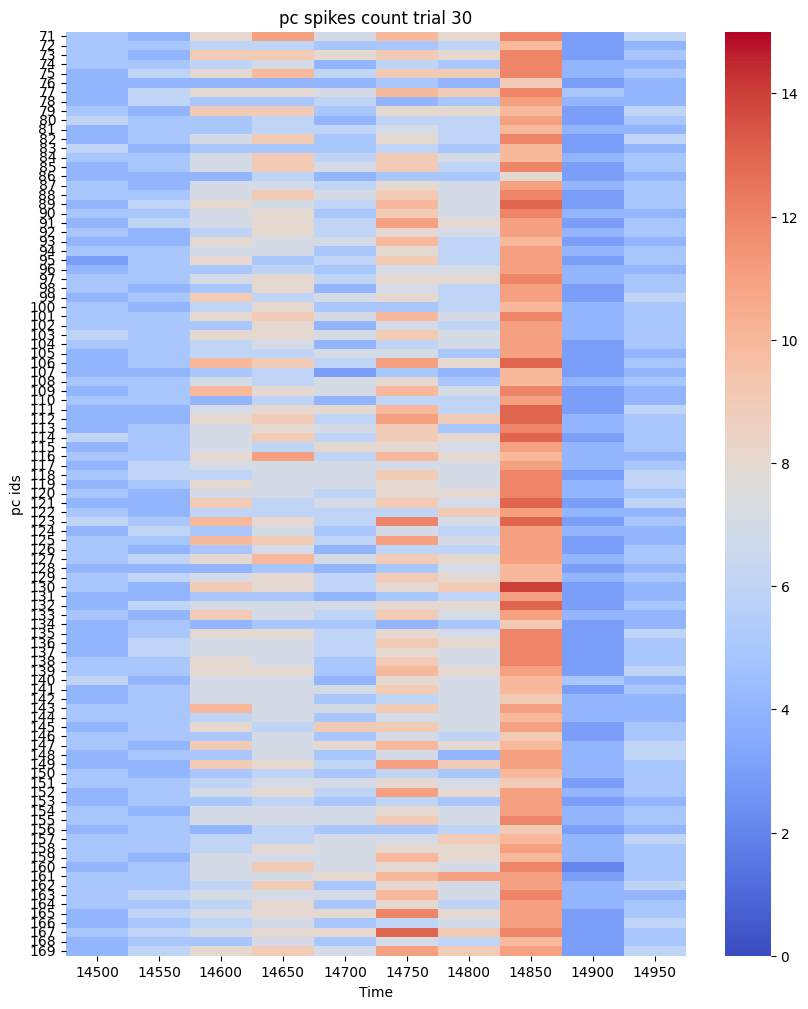

In [41]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(10,12))
sns.heatmap(pc_spikes_matrix_trial_30, 
            cmap = cmap, 
            xticklabels=range(intervals[1][0], intervals[1][1], time_bin), 
            yticklabels=pc_ids,
            vmin = 0,
            vmax = 15
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('pc spikes count trial 30')

In [39]:
pc_spikes_matrix_trial_diff = pc_spikes_matrix_trial_30 - pc_spikes_matrix_trial_2

/tmp/ipykernel_2991295/1446084239.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm')


Text(0.5, 1.0, 'pc spikes count trial diff')

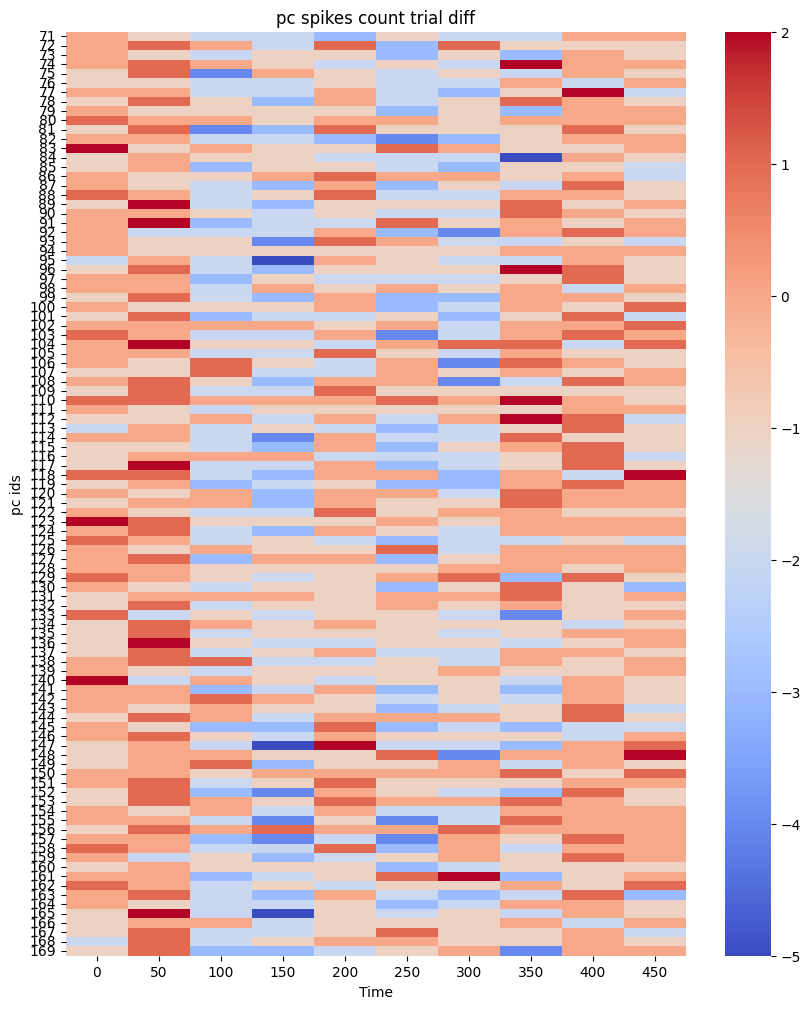

In [49]:
cmap = plt.cm.get_cmap('coolwarm')
plt.figure(figsize=(10,12))
sns.heatmap(pc_spikes_matrix_trial_diff, 
            cmap = cmap, 
            xticklabels=np.arange(0, 500, time_bin), 
            yticklabels=pc_ids,
            )
plt.xlabel('Time')
plt.ylabel('pc ids')
plt.title('pc spikes count trial diff')